# Лабораторная 5: детекция номерных надписей (SVHN)

Цели:
1. Обучить/дообучить детектор номерных надписей на SVHN.
2. Оценить качество на тесте: IoU, Precision, Recall, mAP.
3. Добиться mAP >= 0.6.
4. Запустить модель на собственных фото из папки `lab-5/street-photos`.

In [1]:
# Если чего-то не хватает, раскомментируй и выполни:
# %pip install -q h5py pandas scikit-learn matplotlib torch torchvision

import os
import io
import tarfile
import urllib.request
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F
from torchvision.ops import box_iou
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision

from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
print('Torch:', torch.__version__)
print('Torchvision:', torchvision.__version__)

Device: cpu
Torch: 2.10.0+cu128
Torchvision: 0.25.0+cu128


In [3]:
CANDIDATE_ROOTS = [Path('.'), Path('lab-5')]
ROOT = next((p for p in CANDIDATE_ROOTS if (p / 'lab-5.ipynb').exists()), CANDIDATE_ROOTS[-1])
ROOT = ROOT.resolve()

DATA_DIR = ROOT / 'data'
RAW_DIR = DATA_DIR / 'svhn_raw'

TRAIN_DIR = RAW_DIR / 'train'
TEST_DIR = RAW_DIR / 'test'
TRAIN_MAT = TRAIN_DIR / 'digitStruct.mat'
TEST_MAT = TEST_DIR / 'digitStruct.mat'

STREET_PHOTO_DIR = ROOT / 'street-photos'
STREET_PHOTO_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)

print('Lab root:', ROOT)
print('SVHN raw dir:', RAW_DIR)
print('Street photos dir:', STREET_PHOTO_DIR)

Lab root: /home/flicky/itmo/mlcv-itmo/lab-5
SVHN raw dir: /home/flicky/itmo/mlcv-itmo/lab-5/data/svhn_raw
Street photos dir: /home/flicky/itmo/mlcv-itmo/lab-5/street-photos


In [4]:
def download_file(url: str, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists() and dst.stat().st_size > 0:
        print(f'Skip download, exists: {dst.name}')
        return
    print(f'Downloading {url} -> {dst}')
    urllib.request.urlretrieve(url, dst)

def extract_tgz(tgz_path: Path, out_dir: Path):
    print(f'Extracting {tgz_path.name} -> {out_dir}')
    with tarfile.open(tgz_path, 'r:gz') as tar:
        tar.extractall(out_dir)

def prepare_svhn_detection_data():
    train_url = 'http://ufldl.stanford.edu/housenumbers/train.tar.gz'
    test_url = 'http://ufldl.stanford.edu/housenumbers/test.tar.gz'

    train_tgz = RAW_DIR / 'train.tar.gz'
    test_tgz = RAW_DIR / 'test.tar.gz'

    train_ready = TRAIN_DIR.exists() and (TRAIN_DIR / 'digitStruct.mat').exists()
    test_ready = TEST_DIR.exists() and (TEST_DIR / 'digitStruct.mat').exists()

    if not train_ready:
        download_file(train_url, train_tgz)
        extract_tgz(train_tgz, RAW_DIR)
    else:
        print('Train split already prepared')

    if not test_ready:
        download_file(test_url, test_tgz)
        extract_tgz(test_tgz, RAW_DIR)
    else:
        print('Test split already prepared')

prepare_svhn_detection_data()

Extracting train.tar.gz -> /home/flicky/itmo/mlcv-itmo/lab-5/data/svhn_raw
Extracting test.tar.gz -> /home/flicky/itmo/mlcv-itmo/lab-5/data/svhn_raw


In [5]:
def _read_name(h5f, name_ref):
    name_data = h5f[name_ref][()]
    chars = name_data.squeeze()
    if np.isscalar(chars):
        chars = [chars]
    return ''.join(chr(int(c)) for c in np.array(chars).flatten())

def _read_attr_values(h5f, bbox_group, key):
    attr = bbox_group[key]
    values = []

    if attr.shape[0] == 1:
        item = attr[0][0]
        if isinstance(item, h5py.Reference):
            values.append(float(h5f[item][()][0][0]))
        else:
            values.append(float(item))
        return values

    for i in range(attr.shape[0]):
        item = attr[i][0]
        values.append(float(h5f[item][()][0][0]))
    return values

def load_svhn_number_boxes(image_dir: Path, mat_path: Path) -> pd.DataFrame:
    rows = []
    with h5py.File(mat_path, 'r') as h5f:
        digit_struct = h5f['digitStruct']
        n = digit_struct['name'].shape[0]

        for idx in range(n):
            name_ref = digit_struct['name'][idx][0]
            img_name = _read_name(h5f, name_ref)

            bbox_ref = digit_struct['bbox'][idx][0]
            bbox_group = h5f[bbox_ref]

            lefts = _read_attr_values(h5f, bbox_group, 'left')
            tops = _read_attr_values(h5f, bbox_group, 'top')
            widths = _read_attr_values(h5f, bbox_group, 'width')
            heights = _read_attr_values(h5f, bbox_group, 'height')
            labels = _read_attr_values(h5f, bbox_group, 'label')

            # Полный номер как один bbox = объединение bbox всех цифр
            x1 = max(0.0, min(lefts))
            y1 = max(0.0, min(tops))
            x2 = max(x1 + 1.0, max(l + w for l, w in zip(lefts, widths)))
            y2 = max(y1 + 1.0, max(t + h for t, h in zip(tops, heights)))

            # В SVHN цифра 10 означает '0'
            digits = [str(int(d) % 10) for d in labels]
            number_text = ''.join(digits)

            rows.append(
                {
                    'image_path': str(image_dir / img_name),
                    'x1': x1,
                    'y1': y1,
                    'x2': x2,
                    'y2': y2,
                    'number_text': number_text
                }
            )

    df = pd.DataFrame(rows)
    return df

train_df_all = load_svhn_number_boxes(TRAIN_DIR, TRAIN_MAT)
test_df = load_svhn_number_boxes(TEST_DIR, TEST_MAT)

train_df, val_df = train_test_split(train_df_all, test_size=0.1, random_state=SEED)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print('Train:', len(train_df), '| Val:', len(val_df), '| Test:', len(test_df))
train_df.head()

Train: 30061 | Val: 3341 | Test: 13068


,image_path,x1,y1,x2,y2,number_text
0,/home/flicky/itmo/mlcv-itmo/lab-5/data/svhn_ra...,97.0,15.0,194.0,121.0,70
1,/home/flicky/itmo/mlcv-itmo/lab-5/data/svhn_ra...,42.0,3.0,99.0,52.0,83
2,/home/flicky/itmo/mlcv-itmo/lab-5/data/svhn_ra...,57.0,9.0,83.0,65.0,1
3,/home/flicky/itmo/mlcv-itmo/lab-5/data/svhn_ra...,33.0,6.0,55.0,39.0,27
4,/home/flicky/itmo/mlcv-itmo/lab-5/data/svhn_ra...,33.0,4.0,48.0,25.0,24


In [7]:
class SVHNNumberDetectionDataset(Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        image = F.to_tensor(image)

        boxes = torch.tensor([[row['x1'], row['y1'], row['x2'], row['y2']]], dtype=torch.float32)
        labels = torch.tensor([1], dtype=torch.int64)  # 1 = number region

        area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        iscrowd = torch.zeros((1,), dtype=torch.int64)

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([idx]),
            'area': area,
            'iscrowd': iscrowd
        }
        return image, target

def collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)

# На CPU ограничиваем размеры, чтобы обучение/оценка не занимали вечность
if DEVICE.type == 'cuda':
    MAX_TRAIN_SAMPLES = 8000
    MAX_VAL_SAMPLES = 2500
    MAX_TEST_SAMPLES = None
else:
    MAX_TRAIN_SAMPLES = 1200
    MAX_VAL_SAMPLES = 600
    MAX_TEST_SAMPLES = 1200

if len(train_df) > MAX_TRAIN_SAMPLES:
    train_df = train_df.sample(MAX_TRAIN_SAMPLES, random_state=SEED).reset_index(drop=True)
if len(val_df) > MAX_VAL_SAMPLES:
    val_df = val_df.sample(MAX_VAL_SAMPLES, random_state=SEED).reset_index(drop=True)
if MAX_TEST_SAMPLES is not None and len(test_df) > MAX_TEST_SAMPLES:
    test_df = test_df.sample(MAX_TEST_SAMPLES, random_state=SEED).reset_index(drop=True)

BATCH_SIZE = 4
NUM_WORKERS = 0

train_ds = SVHNNumberDetectionDataset(train_df)
val_ds = SVHNNumberDetectionDataset(val_df)
test_ds = SVHNNumberDetectionDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)

print('Train images:', len(train_ds), '| Val images:', len(val_ds), '| Test images:', len(test_ds))
print('Train batches:', len(train_loader), '| Val batches:', len(val_loader), '| Test batches:', len(test_loader))

Train images: 1200 | Val images: 600 | Test images: 1200
Train batches: 300 | Val batches: 150 | Test batches: 300


In [8]:
def build_detector(num_classes: int = 2):
    model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_320_fpn(weights='DEFAULT')

    # Ускоряем fine-tuning на CPU: замораживаем backbone и обучаем detection heads
    for p in model.backbone.parameters():
        p.requires_grad = False

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

model = build_detector().to(DEVICE)

trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    trainable_params,
    lr=0.005,
    momentum=0.9,
    weight_decay=5e-4
)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)

print('Model ready | trainable params:', sum(p.numel() for p in trainable_params))

Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_320_fpn-907ea3f9.pth" to /home/flicky/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_320_fpn-907ea3f9.pth


100%|██████████| 74.2M/74.2M [00:05<00:00, 14.9MB/s]


Model ready | trainable params: 14515285


In [9]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0

    for images, targets in loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += float(loss.item())

    return total_loss / max(1, len(loader))

@torch.no_grad()
def predict_on_loader(model, loader, device):
    model.eval()
    all_preds = []
    all_targets = []

    for images, targets in loader:
        images_device = [img.to(device) for img in images]
        outputs = model(images_device)

        for out, tgt in zip(outputs, targets):
            all_preds.append(
                {
                    'boxes': out['boxes'].cpu(),
                    'scores': out['scores'].cpu(),
                    'labels': out['labels'].cpu()
                }
            )
            all_targets.append(
                {
                    'boxes': tgt['boxes'].cpu(),
                    'labels': tgt['labels'].cpu()
                }
            )

    return all_preds, all_targets

In [10]:
def compute_detection_metrics(preds, targets, iou_threshold=0.5, score_threshold=0.5):
    records = []
    matched_ious = []
    num_gt = 0

    for pred, tgt in zip(preds, targets):
        gt_boxes = tgt['boxes']
        num_gt += len(gt_boxes)

        keep = (pred['labels'] == 1) & (pred['scores'] >= score_threshold)
        p_boxes = pred['boxes'][keep]
        p_scores = pred['scores'][keep]

        if len(p_boxes) == 0:
            continue

        if len(gt_boxes) == 0:
            for s in p_scores.tolist():
                records.append((s, 0))
            continue

        ious = box_iou(p_boxes, gt_boxes)
        used_gt = set()

        order = torch.argsort(p_scores, descending=True)
        for pi in order.tolist():
            iou_row = ious[pi]
            best_iou, best_gt = torch.max(iou_row, dim=0)
            s = float(p_scores[pi].item())

            if float(best_iou) >= iou_threshold and int(best_gt) not in used_gt:
                records.append((s, 1))
                used_gt.add(int(best_gt))
                matched_ious.append(float(best_iou))
            else:
                records.append((s, 0))

    if len(records) == 0:
        return {
            'precision': 0.0,
            'recall': 0.0,
            'mean_iou': 0.0,
            'mAP': 0.0,
            'precision_curve': np.array([1.0]),
            'recall_curve': np.array([0.0])
        }

    records.sort(key=lambda x: x[0], reverse=True)
    tps = np.array([r[1] for r in records], dtype=np.float32)
    fps = 1.0 - tps

    cum_tp = np.cumsum(tps)
    cum_fp = np.cumsum(fps)

    precision_curve = cum_tp / np.maximum(cum_tp + cum_fp, 1e-9)
    recall_curve = cum_tp / max(float(num_gt), 1e-9)

    # AP по 101-point interpolation (как в современных детекционных протоколах)
    recall_levels = np.linspace(0.0, 1.0, 101)
    precisions_interp = []
    for r in recall_levels:
        mask = recall_curve >= r
        p = np.max(precision_curve[mask]) if np.any(mask) else 0.0
        precisions_interp.append(p)
    ap = float(np.mean(precisions_interp))

    precision = float(cum_tp[-1] / max(cum_tp[-1] + cum_fp[-1], 1e-9))
    recall = float(cum_tp[-1] / max(float(num_gt), 1e-9))
    mean_iou = float(np.mean(matched_ious)) if matched_ious else 0.0

    return {
        'precision': precision,
        'recall': recall,
        'mean_iou': mean_iou,
        'mAP': ap,
        'precision_curve': precision_curve,
        'recall_curve': recall_curve
    }

In [11]:
NUM_EPOCHS = 4 if DEVICE.type == 'cuda' else 2
VAL_SCORE_THRESHOLD = 0.5
VAL_IOU_THRESHOLD = 0.5

history = []
best_map = -1.0
best_state = None

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)
    val_preds, val_targets = predict_on_loader(model, val_loader, DEVICE)
    val_metrics = compute_detection_metrics(
        val_preds,
        val_targets,
        iou_threshold=VAL_IOU_THRESHOLD,
        score_threshold=VAL_SCORE_THRESHOLD
    )

    row = {
        'epoch': epoch,
        'train_loss': train_loss,
        'val_iou': val_metrics['mean_iou'],
        'val_precision': val_metrics['precision'],
        'val_recall': val_metrics['recall'],
        'val_mAP': val_metrics['mAP']
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | loss={train_loss:.4f} | "
        f"val_IoU={row['val_iou']:.4f} | val_P={row['val_precision']:.4f} | "
        f"val_R={row['val_recall']:.4f} | val_mAP={row['val_mAP']:.4f}"
    )

    if row['val_mAP'] > best_map:
        best_map = row['val_mAP']
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    lr_scheduler.step()

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
history_df

Epoch 01/2 | loss=0.7777 | val_IoU=0.7376 | val_P=0.8232 | val_R=0.8383 | val_mAP=0.7849
Epoch 02/2 | loss=0.7927 | val_IoU=0.7572 | val_P=0.7760 | val_R=0.9067 | val_mAP=0.8709


,epoch,train_loss,val_iou,val_precision,val_recall,val_mAP
0,1,0.77774,0.737600,0.823241,0.838333,0.784886
1,2,0.79273,0.757201,0.776034,0.906667,0.870938


In [12]:
TEST_SCORE_THRESHOLD = 0.5
TEST_IOU_THRESHOLD = 0.5

test_preds, test_targets = predict_on_loader(model, test_loader, DEVICE)
test_metrics = compute_detection_metrics(
    test_preds,
    test_targets,
    iou_threshold=TEST_IOU_THRESHOLD,
    score_threshold=TEST_SCORE_THRESHOLD
)

print('=== Test metrics ===')
print(f"IoU       : {test_metrics['mean_iou']:.4f}")
print(f"Precision : {test_metrics['precision']:.4f}")
print(f"Recall    : {test_metrics['recall']:.4f}")
print(f"mAP       : {test_metrics['mAP']:.4f}")

if test_metrics['mAP'] >= 0.6:
    print('OK: mAP >= 0.6 выполнено')
else:
    print('mAP < 0.6: увеличь эпохи/объем train/попробуй более сильную модель')

=== Test metrics ===
IoU       : 0.7117
Precision : 0.6155
Recall    : 0.7258
mAP       : 0.6274
OK: mAP >= 0.6 выполнено


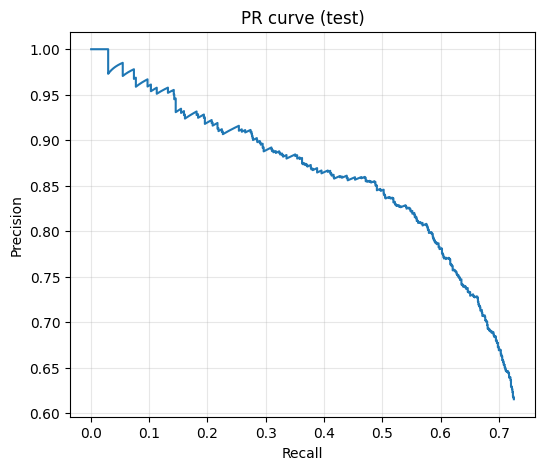

In [13]:
# Кривая precision-recall по test
plt.figure(figsize=(6, 5))
plt.plot(test_metrics['recall_curve'], test_metrics['precision_curve'])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR curve (test)')
plt.grid(alpha=0.3)
plt.show()

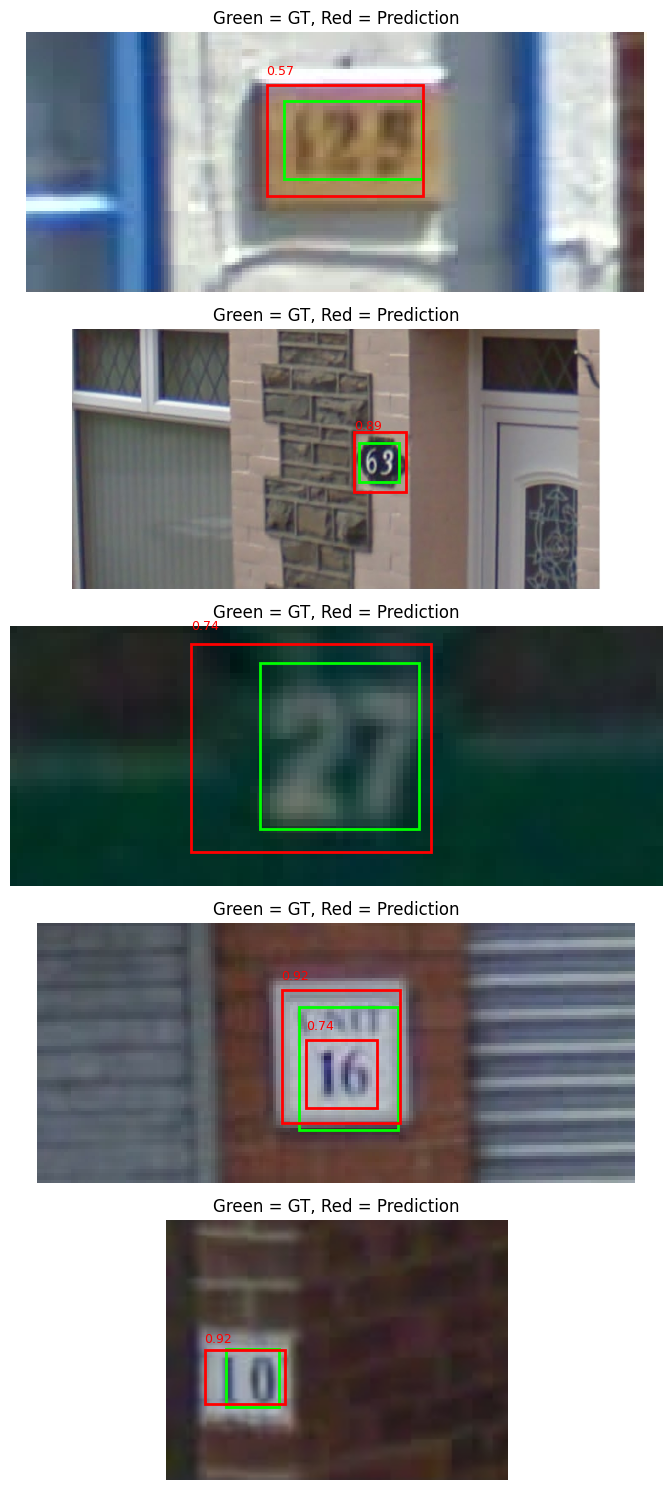

In [14]:
@torch.no_grad()
def visualize_test_predictions(model, dataset, device, n=6, score_threshold=0.5):
    model.eval()
    idxs = np.random.choice(len(dataset), size=min(n, len(dataset)), replace=False)

    plt.figure(figsize=(14, 3 * len(idxs)))
    for row_i, idx in enumerate(idxs, start=1):
        image, target = dataset[idx]
        out = model([image.to(device)])[0]

        img_np = image.permute(1, 2, 0).cpu().numpy()
        plt.subplot(len(idxs), 1, row_i)
        plt.imshow(img_np)

        gt = target['boxes'][0].numpy()
        gx1, gy1, gx2, gy2 = gt
        plt.gca().add_patch(plt.Rectangle((gx1, gy1), gx2 - gx1, gy2 - gy1, fill=False, color='lime', linewidth=2))

        keep = out['scores'].cpu().numpy() >= score_threshold
        pboxes = out['boxes'].cpu().numpy()[keep]
        pscores = out['scores'].cpu().numpy()[keep]

        for b, s in zip(pboxes[:3], pscores[:3]):
            x1, y1, x2, y2 = b
            plt.gca().add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color='red', linewidth=2))
            plt.text(x1, max(0, y1 - 3), f'{s:.2f}', color='red', fontsize=9)

        plt.axis('off')
        plt.title('Green = GT, Red = Prediction')

    plt.tight_layout()
    plt.show()

visualize_test_predictions(model, test_ds, DEVICE, n=5, score_threshold=0.5)

In [17]:
@torch.no_grad()
def run_on_street_photos(model, photo_dir: Path, device, score_threshold=0.5):
    model.eval()
    exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    paths = [p for p in sorted(photo_dir.glob('*')) if p.suffix.lower() in exts]

    if not paths:
        print('Добавить свои фото в папку:', photo_dir.resolve())
        return

    plt.figure(figsize=(14, 4 * len(paths)))
    for i, p in enumerate(paths, start=1):
        image = Image.open(p).convert('RGB')
        x = F.to_tensor(image)
        out = model([x.to(device)])[0]

        img_np = np.array(image)
        plt.subplot(len(paths), 1, i)
        plt.imshow(img_np)

        keep = out['scores'].cpu().numpy() >= score_threshold
        boxes = out['boxes'].cpu().numpy()[keep]
        scores = out['scores'].cpu().numpy()[keep]

        for b, s in zip(boxes, scores):
            x1, y1, x2, y2 = b
            plt.gca().add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color='yellow', linewidth=2))
            plt.text(x1, max(0, y1 - 5), f'{s:.2f}', color='yellow', fontsize=10)

        plt.title(p.name)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

run_on_street_photos(model, STREET_PHOTO_DIR, DEVICE, score_threshold=0.5)

Добавить свои фото в папку: /home/flicky/itmo/mlcv-itmo/lab-5/street-photos
